In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:\AI-Based Indian Grocery Segmentation using Clustering\data\GroceryDataset.csv")
df.head(2)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\AI-Based Indian Grocery Segmentation using Clustering\\data\\GroceryDataset.csv'

In [ ]:
df.shape

(1757, 8)

In [ ]:
df.info()
df.describe(include="all").T
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sub Category         1757 non-null   object
 1   Price                1754 non-null   object
 2   Discount             1757 non-null   object
 3   Rating               682 non-null    object
 4   Title                1757 non-null   object
 5   Currency             1752 non-null   object
 6   Feature              1739 non-null   object
 7   Product Description  1715 non-null   object
dtypes: object(8)
memory usage: 109.9+ KB


Index(['Sub Category', 'Price', 'Discount', 'Rating', 'Title', 'Currency',
       'Feature', 'Product Description'],
      dtype='object')

In [ ]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing_Count"] > 0]

missing

,Missing_Count,Missing_%
Price,3,0.17
Rating,1075,61.18
Currency,5,0.28
Feature,18,1.02
Product Description,42,2.39


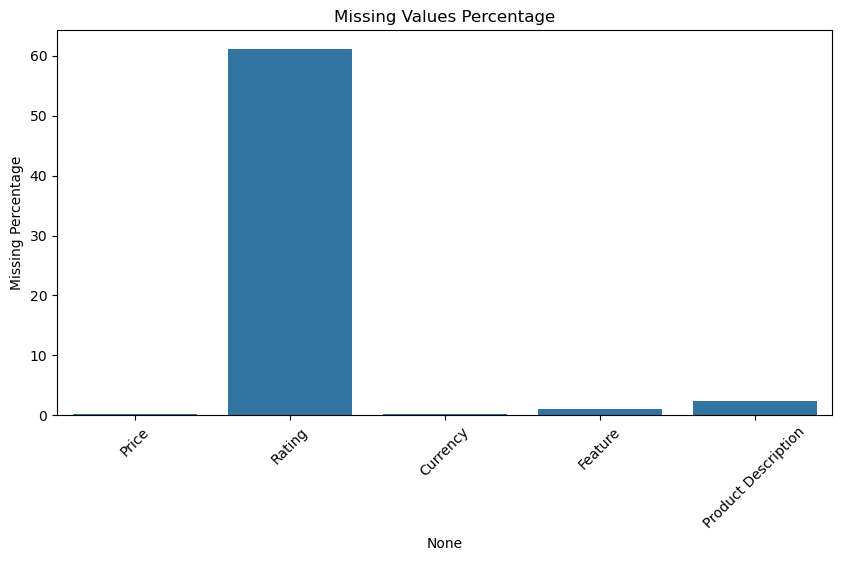

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Missing_%"]
)

plt.xticks(rotation=45)
plt.ylabel("Missing Percentage")
plt.title("Missing Values Percentage")
plt.show()

In [ ]:
df.shape

(1757, 8)

In [ ]:
missing


,Missing_Count,Missing_%
Price,3,0.17
Rating,1075,61.18
Currency,5,0.28
Feature,18,1.02
Product Description,42,2.39


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 3


,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description
1344,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...
1345,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...
1346,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Sub Category: 19 unique values
Price: 184 unique values
Discount: 42 unique values
Rating: 483 unique values
Title: 1484 unique values
Currency: 1 unique values
Feature: 1401 unique values
Product Description: 1435 unique values


In [ ]:
print(df["Sub Category"].value_counts())

Sub Category
Snacks                          293
Pantry & Dry Goods              171
Candy                           154
Beverages & Water               148
Meat & Seafood                  144
Kirkland Signature Grocery      122
Coffee                           95
Cleaning Supplies                94
Gift Baskets                     89
Paper & Plastic Products         85
Household                        81
Floral                           75
Seafood                          47
Laundry Detergent & Supplies     39
Organic                          33
Bakery & Desserts                33
Deli                             21
Breakfast                        21
Poultry                           9
Name: count, dtype: int64


In [ ]:
df.dtypes

Sub Category           object
Price                  object
Discount               object
Rating                 object
Title                  object
Currency               object
Feature                object
Product Description    object
dtype: object

Price Feature Extraction

In [ ]:
df["Price_num"] = (
    df["Price"]
    .astype(str)
    .str.extract(r"([\d,.]+)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
df[["Price", "Price_num"]].head()

,Price,Price_num
0,$56.99,56.99
1,$159.99,159.99
2,$44.99,44.99
3,$39.99,39.99
4,$59.99,59.99


In [ ]:
df["Price_num"].describe()

count    1751.000000
mean       60.871302
std       120.746672
min         3.990000
25%        14.990000
50%        23.990000
75%        52.890000
max      1999.990000
Name: Price_num, dtype: float64

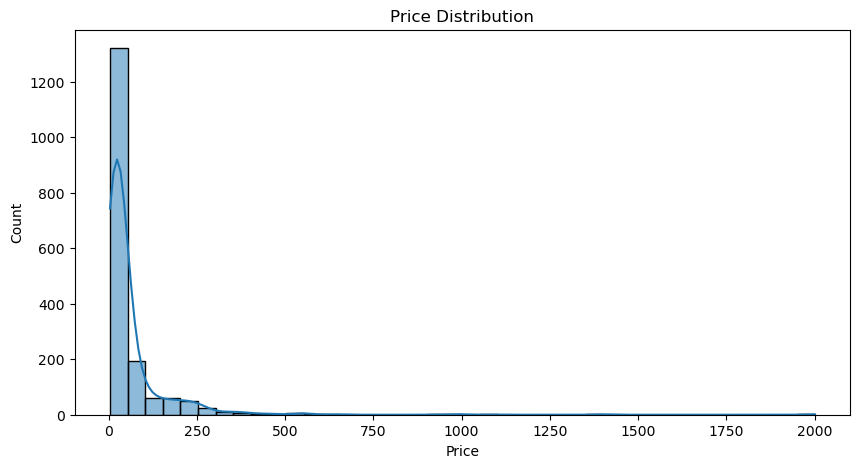

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price_num"], bins=40, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

Discount Feature Extraction

In [ ]:
df["Discount_num"] = (
    df["Discount"]
    .astype(str)
    .str.extract(r"After \$([\d,.]+) OFF")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
    .fillna(0)
)

In [ ]:
df[["Discount", "Discount_num"]].head(20)

,Discount,Discount_num
0,No Discount,0.0
1,No Discount,0.0
2,No Discount,0.0
3,No Discount,0.0
4,No Discount,0.0
5,No Discount,0.0
6,No Discount,0.0
7,No Discount,0.0
8,No Discount,0.0
9,No Discount,0.0


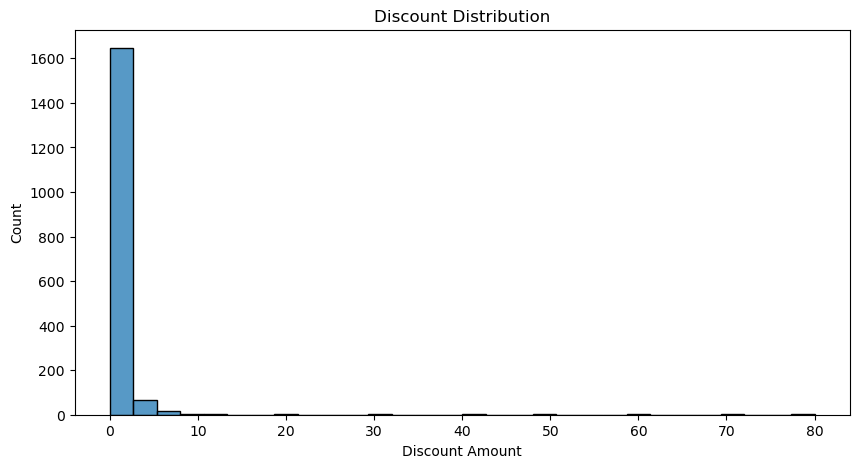

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Discount_num"], bins=30)

plt.title("Discount Distribution")
plt.xlabel("Discount Amount")
plt.show()

In [ ]:
df["Discount_num"].gt(0).value_counts()

Discount_num
False    1634
True      120
Name: count, dtype: int64

Rating + Reviews Extraction

In [ ]:
df["Rating_num"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"Rated\s+([0-9.]+)")[0]
    .astype(float)
)

In [ ]:
df["Reviews_num"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"based on\s+([\d,]+)\s+reviews")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)


In [ ]:
df[
    ["Rating", "Rating_num", "Reviews_num"]
].head(10)

,Rating,Rating_num,Reviews_num
0,Rated 4.3 out of 5 stars based on 265 reviews.,4.3,265.0
1,Rated 5 out of 5 stars based on 1 reviews.,5.0,1.0
2,Rated 4.1 out of 5 stars based on 441 reviews.,4.1,441.0
3,Rated 4.7 out of 5 stars based on 9459 reviews.,4.7,9459.0
4,Rated 4.5 out of 5 stars based on 758 reviews.,4.5,758.0
5,Rated 4.4 out of 5 stars based on 369 reviews.,4.4,369.0
6,Rated 4.7 out of 5 stars based on 2241 reviews.,4.7,2241.0
7,Rated 4.4 out of 5 stars based on 232 reviews.,4.4,232.0
8,Rated 4.4 out of 5 stars based on 1679 reviews.,4.4,1679.0
9,Rated 5 out of 5 stars based on 2 reviews.,5.0,2.0


Rating Distribution

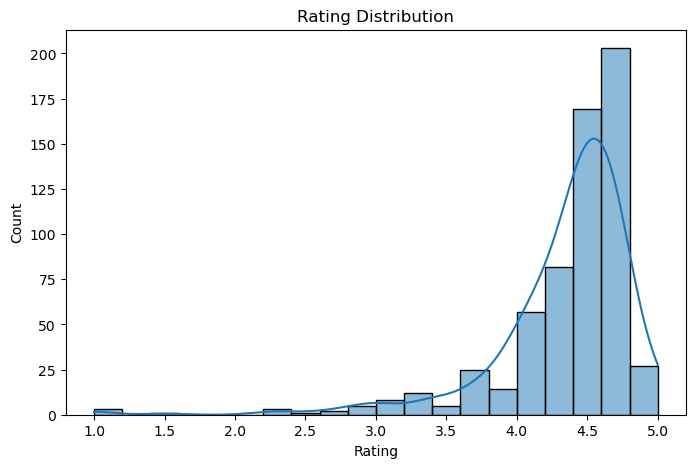

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating_num"].dropna(),
    bins=20,
    kde=True
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.show()

In [ ]:
df["Rating_num"].describe()

count    617.000000
mean       4.340357
std        0.510037
min        1.000000
25%        4.200000
50%        4.500000
75%        4.600000
max        5.000000
Name: Rating_num, dtype: float64

Reviews Distribution

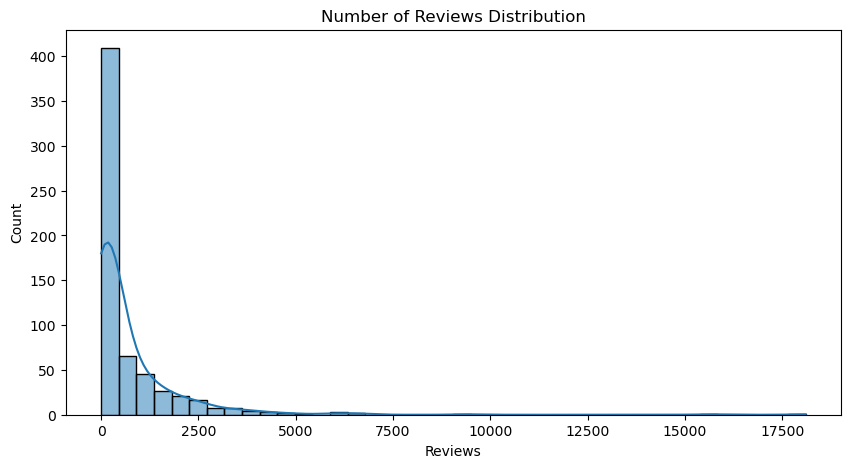

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Reviews_num"].dropna(),
    bins=40,
    kde=True
)

plt.title("Number of Reviews Distribution")
plt.xlabel("Reviews")
plt.show()

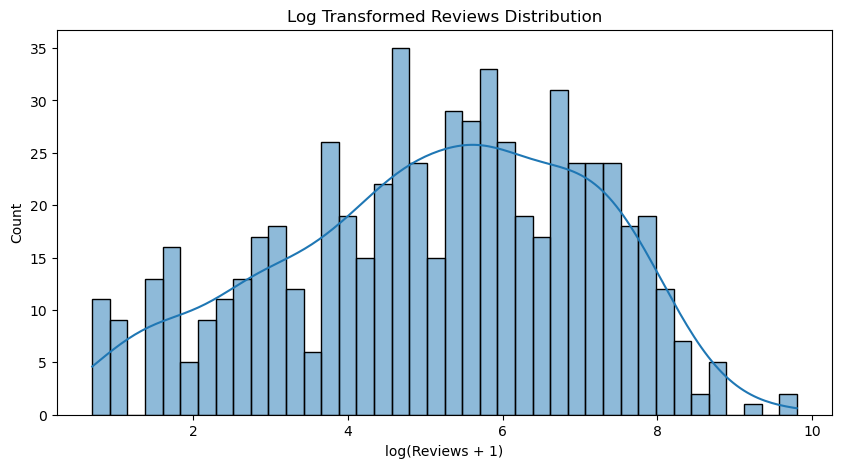

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["Reviews_num"].dropna()),
    bins=40,
    kde=True
)

plt.title("Log Transformed Reviews Distribution")
plt.xlabel("log(Reviews + 1)")
plt.show()

Category Analysis

In [ ]:
category_counts = df["Sub Category"].value_counts()

category_counts

Sub Category
Snacks                          293
Pantry & Dry Goods              171
Candy                           154
Beverages & Water               148
Meat & Seafood                  144
Kirkland Signature Grocery      122
Coffee                           95
Cleaning Supplies                94
Gift Baskets                     89
Paper & Plastic Products         85
Household                        81
Floral                           75
Seafood                          47
Laundry Detergent & Supplies     39
Organic                          33
Bakery & Desserts                33
Deli                             21
Breakfast                        21
Poultry                           9
Name: count, dtype: int64

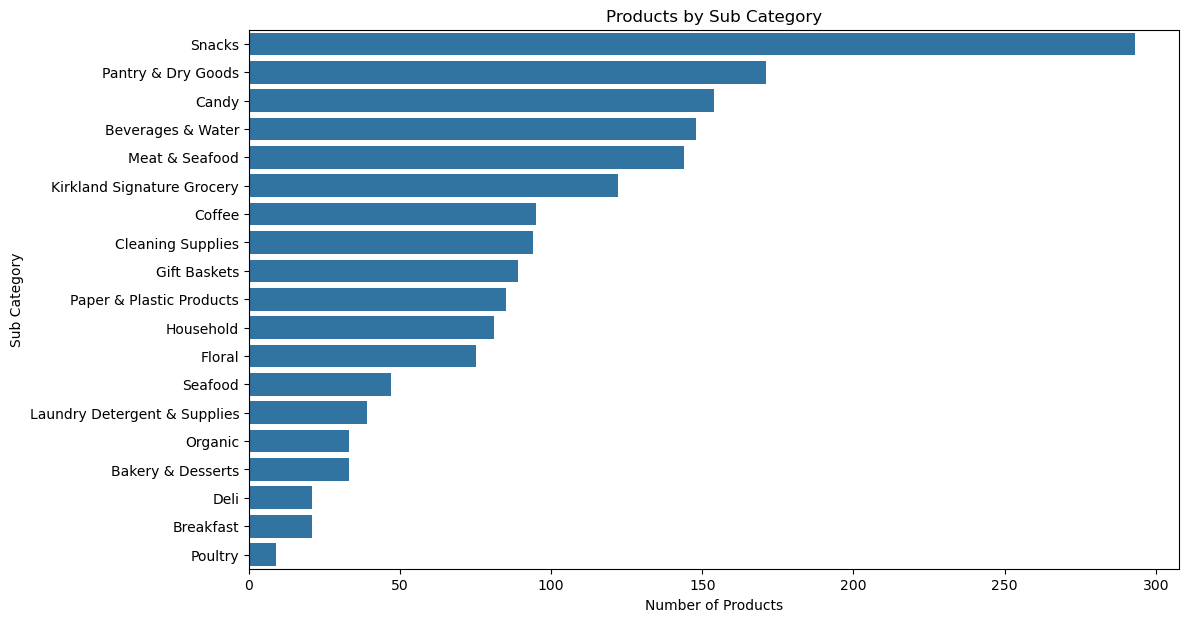

In [ ]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Sub Category",
    order=df["Sub Category"].value_counts().index
)

plt.title("Products by Sub Category")
plt.xlabel("Number of Products")
plt.ylabel("Sub Category")
plt.show()

Category vs Price

In [35]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="Sub Category",
    y="Price_num"
)

plt.xticks(rotation=60)
plt.title("Price Distribution by Category")
plt.show()

NameError: name 'df' is not defined

<Figure size 1400x700 with 0 Axes>

Category Average Price

In [36]:
category_price = (
    df.groupby("Sub Category")["Price_num"]
    .mean()
    .sort_values(ascending=False)
)

category_price

NameError: name 'df' is not defined

In [37]:
plt.figure(figsize=(12,6))

category_price.plot(kind="bar")

plt.title("Average Price by Category")
plt.ylabel("Average Price")
plt.xticks(rotation=60)
plt.show()

NameError: name 'category_price' is not defined

<Figure size 1200x600 with 0 Axes>

Discount Analysis

In [38]:
discount_category = (
    df.groupby("Sub Category")["Discount_num"]
    .mean()
    .sort_values(ascending=False)
)

discount_category

NameError: name 'df' is not defined

In [39]:
plt.figure(figsize=(12,6))

discount_category.plot(kind="bar")

plt.title("Average Discount by Category")
plt.ylabel("Average Discount")
plt.xticks(rotation=60)
plt.show()

NameError: name 'discount_category' is not defined

<Figure size 1200x600 with 0 Axes>

Missing Rating by Category

In [40]:
rating_missing = (
    df.groupby("Sub Category")["Rating_num"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

rating_missing

NameError: name 'df' is not defined

In [42]:
plt.figure(figsize=(12,6))

rating_missing.plot(kind="bar")

plt.ylabel("Missing Rating %")
plt.title("Missing Rating Percentage by Category")
plt.xticks(rotation=60)
plt.show()

NameError: name 'rating_missing' is not defined

<Figure size 1200x600 with 0 Axes>

Outlier Analysis

In [4]:
numeric_cols = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num"
]

In [5]:
for col in numeric_cols:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

NameError: name 'df' is not defined

<Figure size 1000x400 with 0 Axes>

In [6]:
def outlier_count(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return ((data[column] < lower) | (data[column] > upper)).sum()

In [7]:
for col in numeric_cols:
    print(col, ":", outlier_count(df, col))

NameError: name 'df' is not defined

Correlation Analysis

In [8]:
corr_cols = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num"
]

corr = df[corr_cols].corr()

corr

NameError: name 'df' is not defined

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

NameError: name 'corr' is not defined

<Figure size 800x600 with 0 Axes>

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Price_num",
    y="Rating_num"
)

plt.title("Price vs Rating")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Price_num",
    y="Discount_num"
)

plt.title("Price vs Discount")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [12]:
df["Title_Length"] = df["Title"].fillna("").str.len()

NameError: name 'df' is not defined

In [13]:
df["Feature_Length"] = df["Feature"].fillna("").str.len()

NameError: name 'df' is not defined

In [14]:
df["Description_Length"] = (
    df["Product Description"]
    .fillna("")
    .str.len()
)

NameError: name 'df' is not defined

In [15]:
df[
    [
        "Title_Length",
        "Feature_Length",
        "Description_Length"
    ]
].describe()

NameError: name 'df' is not defined

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Title_Length"],
    bins=30,
    kde=True
)

plt.title("Product Title Length Distribution")
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x500 with 0 Axes>

In [17]:
numeric_features = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num",
    "Title_Length",
    "Feature_Length",
    "Description_Length"
]

df[numeric_features].describe().T

NameError: name 'df' is not defined

In [18]:
df.shape

NameError: name 'df' is not defined

In [19]:
df.head()

NameError: name 'df' is not defined

In [20]:
df.info()

NameError: name 'df' is not defined

In [21]:
df.isnull().sum()

NameError: name 'df' is not defined

In [22]:
df.duplicated().sum()

NameError: name 'df' is not defined

In [23]:
df[df["Rating"].notna() & df["Rating_num"].isna()][
    ["Rating", "Rating_num"]
].head(20)

NameError: name 'df' is not defined

In [24]:
print(
    df["Rating"].notna().sum(),
    df["Rating_num"].notna().sum()
)

NameError: name 'df' is not defined

In [25]:

df["Rating"].dropna().head(30).tolist()

NameError: name 'df' is not defined

In [26]:
df["Rating"].dropna().sample(20, random_state=42).tolist()

NameError: name 'df' is not defined

In [27]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing[missing["Missing_Count"] > 0]

NameError: name 'df' is not defined

In [28]:
print("=" * 50)
print("DATASET STATUS")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nNumerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

DATASET STATUS

Shape:


NameError: name 'df' is not defined

In [29]:
df[
    [
        "Price",
        "Price_num",
        "Discount",
        "Discount_num",
        "Rating",
        "Rating_num",
        "Reviews_num"
    ]
].head(10)


NameError: name 'df' is not defined

In [30]:
ml_features = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num",
    "Title_Length",
    "Feature_Length",
    "Description_Length"
]

In [31]:
for col in ml_features:
    df[col] = df[col].fillna(
        df[col].median()
    )

NameError: name 'df' is not defined

In [32]:
df[ml_features].isnull().sum()

NameError: name 'df' is not defined

In [33]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

NameError: name 'df' is not defined

In [34]:
output_path = "../data/GroceryDataset_EDA_Final.csv"

df.to_csv(
    output_path,
    index=False
)

print("Final dataset saved successfully!")
print(output_path)

NameError: name 'df' is not defined